# ML-10 - Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AshenDary/Week1_RunTheStarterNotebooks/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook turns the Week-6 honest grouped model score into a reviewer-facing action queue. The ranking source is `grouped_probability`, re-derived with the same depth-4 `DecisionTreeClassifier`, same seven Week-5 features, and `GroupKFold(client_id)` scoring design.

## 1. Ranked actions + reason codes

The queue ranks pages by the honest grouped score, then uses the same deterministic tie-breakers from Weeks 5-6: higher `impressions_90d`, higher `ctr_gap_score`, then `content_id` as a stable sorter only. The reason codes below are built from the seven real model features and the grouped score, not from the fuller reference pipeline's extra features.

Reason-code thresholds used in code:

| Reason code | Exact threshold |
|---|---|
| `REASON_HIGH_MODEL_RISK` | `grouped_probability >= 0.65` |
| `REASON_LOW_CTR_VISIBLE` | `visible_valid_position == 1` and `ctr_gap_score >= 0.75` |
| `REASON_STALE_VISIBLE` | `visible_valid_position == 1`, `freshness_score >= 0.50`, and `ctr_gap_score < 0.75` |
| `REASON_HIGH_CONFIDENCE_HIGH_VOLUME` | `grouped_probability >= 0.75` and `log_impressions_90d >= log1p(500)` |
| `REASON_HIGH_RISK_LOW_VOLUME` | `grouped_probability >= 0.65` and `log_impressions_90d < log1p(100)` |
| `REASON_PAGE_ONE_DECAY_RISK` | `0 < avg_position <= 10` and `freshness_score >= 0.50` |

The stale-visible archetype connects to the Week-6 paper audit finding that content health peaked around 61-90 days, dropped sharply around 271-365 days, and the 365+ rebound was concentrated in refreshed older pages. The safe reading is selection-aware: refreshed older pages may have been chosen because they already looked like stronger candidates, so the pattern supports review prioritization, not a claim that refresh alone created the rebound.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
N_SPLITS = 5
TREE_MAX_DEPTH = 4
MIN_SAMPLES_LEAF = 100

HIGH_MODEL_RISK = 0.65
HIGH_CONFIDENCE_RISK = 0.75
LOW_CTR_GAP = 0.75
STALE_FRESHNESS_SCORE = 0.50
LOW_VOLUME_LOG_IMPRESSIONS = float(np.log1p(100))
HIGH_VOLUME_LOG_IMPRESSIONS = float(np.log1p(500))
REVIEW_MINUTES_PER_PAGE = 12


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data/warehouse_extract/warehouse_model_frame.parquet").exists():
            return candidate
    raise FileNotFoundError("Could not find data/warehouse_extract/warehouse_model_frame.parquet")


def expected_ctr_by_position(avg_position: pd.Series) -> pd.Series:
    return pd.Series(np.select([avg_position.between(0.01, 3, inclusive="both"), avg_position.between(3.01, 10, inclusive="both"), avg_position.between(10.01, 20, inclusive="both")], [2.00, 1.00, 0.50], default=np.nan), index=avg_position.index)


def build_model_frame(raw_frame: pd.DataFrame) -> pd.DataFrame:
    frame = raw_frame.copy()
    frame["is_declining_label"] = frame["trend_direction"].eq("down").astype(int)
    frame["expected_ctr"] = expected_ctr_by_position(frame["avg_position"])
    frame["visible_valid_position"] = (frame["impressions_90d"].ge(300) & frame["avg_position"].gt(0) & frame["avg_position"].le(20)).astype(int)
    frame["ctr_gap_score"] = ((frame["expected_ctr"] - frame["ctr"]) / frame["expected_ctr"]).clip(lower=0, upper=1).fillna(0.0)
    frame["log_impressions_90d"] = np.log1p(frame["impressions_90d"])
    frame["freshness_score"] = (frame["days_since_last_update"] / 180).clip(lower=0, upper=1)
    return frame


def clean_feature_frame(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    features = frame[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return features.fillna(features.median(numeric_only=True))


def train_tree() -> DecisionTreeClassifier:
    return DecisionTreeClassifier(max_depth=TREE_MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF, class_weight="balanced", random_state=RANDOM_STATE)


def ranked_by_score(frame: pd.DataFrame, score_col: str) -> pd.DataFrame:
    return frame.sort_values([score_col, "impressions_90d", "ctr_gap_score", "content_id"], ascending=[False, False, False, True]).reset_index(drop=True)


def precision_at_k_from_ranked(ranked_frame: pd.DataFrame, k: int) -> float:
    return float(ranked_frame.head(k)["is_declining_label"].mean())


def grouped_oof_scores(X: pd.DataFrame, y: pd.Series, groups: pd.Series) -> np.ndarray:
    scores = np.zeros(len(X), dtype=float)
    for train_idx, test_idx in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        tree = train_tree()
        tree.fit(X.iloc[train_idx], y.iloc[train_idx])
        scores[test_idx] = tree.predict_proba(X.iloc[test_idx])[:, 1]
    return scores


def reason_codes_for_row(row: pd.Series) -> str:
    codes: list[str] = []
    if row["grouped_probability"] >= HIGH_MODEL_RISK: codes.append("REASON_HIGH_MODEL_RISK")
    if row["visible_valid_position"] == 1 and row["ctr_gap_score"] >= LOW_CTR_GAP: codes.append("REASON_LOW_CTR_VISIBLE")
    if row["visible_valid_position"] == 1 and row["freshness_score"] >= STALE_FRESHNESS_SCORE and row["ctr_gap_score"] < LOW_CTR_GAP: codes.append("REASON_STALE_VISIBLE")
    if row["grouped_probability"] >= HIGH_CONFIDENCE_RISK and row["log_impressions_90d"] >= HIGH_VOLUME_LOG_IMPRESSIONS: codes.append("REASON_HIGH_CONFIDENCE_HIGH_VOLUME")
    if row["grouped_probability"] >= HIGH_MODEL_RISK and row["log_impressions_90d"] < LOW_VOLUME_LOG_IMPRESSIONS: codes.append("REASON_HIGH_RISK_LOW_VOLUME")
    if row["avg_position"] > 0 and row["avg_position"] <= 10 and row["freshness_score"] >= STALE_FRESHNESS_SCORE: codes.append("REASON_PAGE_ONE_DECAY_RISK")
    return "|".join(codes) if codes else "REASON_GENERAL_MODEL_RANK"


def assign_archetype(row: pd.Series) -> str:
    codes = set(row["reason_codes"].split("|"))
    if "REASON_HIGH_CONFIDENCE_HIGH_VOLUME" in codes: return "High-confidence decline risk, high volume"
    if "REASON_LOW_CTR_VISIBLE" in codes: return "Visible, underperforming CTR"
    if "REASON_STALE_VISIBLE" in codes or "REASON_PAGE_ONE_DECAY_RISK" in codes: return "Stale but visible"
    if "REASON_HIGH_RISK_LOW_VOLUME" in codes: return "High-risk low-volume watchlist"
    if "REASON_HIGH_MODEL_RISK" in codes: return "Model-risk review candidate"
    return "Lower-priority monitor"


ACTION_BY_ARCHETYPE = {
    "High-confidence decline risk, high volume": "PRIORITY_REVIEW",
    "Visible, underperforming CTR": "FIX_TITLE_META_REFRESH",
    "Stale but visible": "REFRESH_CONTENT",
    "High-risk low-volume watchlist": "MONITOR",
    "Model-risk review candidate": "REVIEW",
    "Lower-priority monitor": "MONITOR",
}

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data/warehouse_extract/warehouse_model_frame.parquet"
BASELINE_METRICS_PATH = REPO_ROOT / "work/outputs/baseline_action_score_metrics.json"
OUTPUT_DIR = REPO_ROOT / "work/outputs"
FIGURE_DIR = REPO_ROOT / "work/figures"
raw_df = pd.read_parquet(DATA_PATH)
baseline_receipt = json.loads(BASELINE_METRICS_PATH.read_text())
model_df = build_model_frame(raw_df)
feature_columns = ["ctr", "avg_position", "visible_valid_position", "ctr_gap_score", "log_impressions_90d", "days_since_last_update", "freshness_score"]
forbidden_inputs = {"trend_direction", "trend_pct", "is_declining_label", "impressions_last_30d", "clicks_last_30d", "sessions_last_30d", "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d", "content_id", "client_id"}
assert set(feature_columns).isdisjoint(forbidden_inputs)
assert len(model_df) == baseline_receipt["rows"]
X = clean_feature_frame(model_df, feature_columns)
y = model_df["is_declining_label"].astype(int)
groups = model_df["client_id"].fillna("unknown").astype(str)
model_df["grouped_probability"] = grouped_oof_scores(X, y, groups)
assert np.isfinite(model_df["grouped_probability"]).all()
ranked_queue = ranked_by_score(model_df, "grouped_probability")
ranked_queue.insert(0, "rank", np.arange(1, len(ranked_queue) + 1))
ranked_queue["reason_codes"] = ranked_queue.apply(reason_codes_for_row, axis=1)
ranked_queue["archetype"] = ranked_queue.apply(assign_archetype, axis=1)
ranked_queue["action_label"] = ranked_queue["archetype"].map(ACTION_BY_ARCHETYPE)
assert ranked_queue["action_label"].notna().all()
reason_counts = ranked_queue["reason_codes"].str.get_dummies(sep="|").sum().sort_values(ascending=False).rename_axis("reason_code").reset_index(name="rows")
archetype_counts = ranked_queue["archetype"].value_counts().rename_axis("archetype").reset_index(name="rows")
action_counts = ranked_queue["action_label"].value_counts().rename_axis("action_label").reset_index(name="rows")
score_summary = pd.DataFrame({"metric": ["rows_scored", "clients", "base_declining_rate", "grouped_precision_at_10", "grouped_precision_at_50", "grouped_precision_at_500", "grouped_roc_auc_diagnostic", "grouped_average_precision_diagnostic"], "value": [len(ranked_queue), ranked_queue["client_id"].nunique(), round(float(y.mean()), 4), round(precision_at_k_from_ranked(ranked_queue, 10), 4), round(precision_at_k_from_ranked(ranked_queue, 50), 4), round(precision_at_k_from_ranked(ranked_queue, 500), 4), round(float(roc_auc_score(y, ranked_queue["grouped_probability"])), 4), round(float(average_precision_score(y, model_df["grouped_probability"])), 4)]})
review_hours_top50 = 50 * REVIEW_MINUTES_PER_PAGE / 60
review_hours_top500 = 500 * REVIEW_MINUTES_PER_PAGE / 60
p50 = precision_at_k_from_ranked(ranked_queue, 50)
p500 = precision_at_k_from_ranked(ranked_queue, 500)
print("Score and validation receipt:")
display(score_summary)
print("Rows by archetype:")
display(archetype_counts)
print("Rows by reason code:")
display(reason_counts)
print("Top 10 queue preview with IDs withheld:")
display(ranked_queue[["rank", "grouped_probability", "reason_codes", "archetype", "action_label", "impressions_90d", "ctr", "avg_position", "days_since_last_update", "ctr_gap_score"]].head(10))
assert 0 <= p50 <= 1 and 0 <= p500 <= 1
assert len(ranked_queue) == len(model_df)
print("Warehouse action queue computed; no starter-data metrics are hard-coded.")

Score and validation receipt:


,metric,value
0,rows_scored,120513.0000
1,clients,41.0000
2,base_declining_rate,0.4329
3,grouped_precision_at_10,0.9000
4,grouped_precision_at_50,0.5200
5,grouped_precision_at_500,0.4720
6,grouped_roc_auc_diagnostic,0.5056
7,grouped_average_precision_diagnostic,0.4764


Rows by archetype:


,archetype,rows
0,Lower-priority monitor,96419
1,"Visible, underperforming CTR",22884
2,"High-confidence decline risk, high volume",703
3,Model-risk review candidate,320
4,Stale but visible,187


Rows by reason code:


,reason_code,rows
0,REASON_GENERAL_MODEL_RANK,96419
1,REASON_LOW_CTR_VISIBLE,23512
2,REASON_HIGH_MODEL_RISK,1392
3,REASON_HIGH_CONFIDENCE_HIGH_VOLUME,703
4,REASON_PAGE_ONE_DECAY_RISK,175
5,REASON_STALE_VISIBLE,26


Top 10 queue preview with IDs withheld:


,rank,grouped_probability,reason_codes,archetype,action_label,impressions_90d,ctr,avg_position,days_since_last_update,ctr_gap_score
0,1,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,2941.0,0.306018,28.613447,18.0,0.0
1,2,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,1381.0,0.000000,73.107738,18.0,0.0
2,3,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,1331.0,0.075131,45.098508,18.0,0.0
3,4,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,1234.0,0.000000,65.866469,18.0,0.0
4,5,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,1196.0,0.083612,55.627272,18.0,0.0
5,6,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,930.0,0.107527,29.124618,18.0,0.0
6,7,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,930.0,0.107527,42.937404,18.0,0.0
7,8,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,914.0,0.000000,39.486283,18.0,0.0
8,9,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,892.0,0.000000,39.042705,18.0,0.0
9,10,0.845633,REASON_HIGH_MODEL_RISK|REASON_HIGH_CONFIDENCE_...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,887.0,0.112740,44.533289,18.0,0.0


Warehouse action queue computed; no starter-data metrics are hard-coded.


## 2. Intended use and limits

This queue ranks pages for a human reviewer to inspect first. It does not decide, publish, edit, de-index, bill, or make client-facing performance judgments by itself.

Limits:

- Single March development snapshot, not a time-aware panel. The observed score is useful for queue ordering on this slice, but it is not a forward-looking outcome claim.
- The March frame contains 41 observed pseudonymized clients, drawn from the 104-client warehouse dimension, with uneven row counts. The grouped audit showed that client composition affects validation, so a new or very different client mix needs revalidation before this ranking is trusted.
- The target is a proxy label derived from March 1-15 versus March 16-31 impressions. It is not a verified future recovery outcome.
- The March label rate was 43.29% and the June held-out label rate was 64.80%; this shift was not investigated further given the available time and should be treated as a limitation.
- The depth-4 tree is intentionally simple. It may miss patterns a richer model catches, but it stays readable for a non-technical reviewer, which is the design goal here.
- The stale/refresh connection is observational. Refreshed older pages may have been selected because they already looked promising, so this queue supports review prioritization rather than causal refresh claims.

In [2]:
limits_table = pd.DataFrame(
    [
        {
            "limit": "single_snapshot",
            "what_it_means": "The starter data is one trailing-90-day snapshot.",
            "decision_rule": "Use the queue for current review ordering, not forward outcome claims.",
        },
        {
            "limit": "client_mix",
            "what_it_means": "The model was validated across 41 observed pseudonymized clients with uneven fold sizes.",
            "decision_rule": "Revalidate before using the ranking for very different client populations.",
        },
        {
            "limit": "proxy_target",
            "what_it_means": "The label is trend_direction == down, not a verified future recovery outcome.",
            "decision_rule": "Describe pages as review candidates, not certain wins.",
        },
        {
            "limit": "simple_model",
            "what_it_means": "A depth-4 tree favors explainability over maximum pattern capture.",
            "decision_rule": "Use reason codes and human checks before action.",
        },
    ]
)
display(limits_table)
assert set(limits_table["limit"]) == {"single_snapshot", "client_mix", "proxy_target", "simple_model"}

,limit,what_it_means,decision_rule
0,single_snapshot,The starter data is one trailing-90-day snapshot.,"Use the queue for current review ordering, not..."
1,client_mix,The model was validated across 41 observed pse...,Revalidate before using the ranking for very d...
2,proxy_target,"The label is trend_direction == down, not a ve...","Describe pages as review candidates, not certa..."
3,simple_model,A depth-4 tree favors explainability over maxi...,Use reason codes and human checks before action.


## 3. Human review + the no-go list

Before acting on any row, a reviewer checks that the page is still live, the content is accurate, the page has enough volume to matter, and the measured drop is not better explained by a sibling page absorbing demand, a calendar-driven dip, SERP or AI click loss, or small-sample noise.

No-go list:

- No auto-publishing or auto-editing content from this queue.
- No auto-deprioritizing or de-indexing content based on the score alone.
- No client-facing billing, contract, or performance decisions based on this score.
- No extrapolating the ranking to clients or content types outside the 41 observed March clients without revalidating first.

In [3]:
human_review_checklist = pd.DataFrame(
    [
        {
            "check": "page_live",
            "question": "Is the page still live and indexable?",
            "reason": "A dead or redirected page needs a different workflow than refresh review.",
        },
        {
            "check": "content_accuracy",
            "question": "Is the content still factually accurate and current?",
            "reason": "Accuracy problems change the action from metadata tuning to content repair.",
        },
        {
            "check": "consolidation",
            "question": "Did a sibling page absorb the same demand?",
            "reason": "A transfer inside the same site is not the same problem as standalone decline.",
        },
        {
            "check": "seasonality",
            "question": "Does the topic normally dip in this calendar period?",
            "reason": "A calendar-driven dip needs monitoring or seasonal planning, not a panic refresh.",
        },
        {
            "check": "serp_or_ai_click_loss",
            "question": "Are impressions and position steady while clicks drop?",
            "reason": "SERP layout or AI referral changes can reduce clicks without content decay.",
        },
        {
            "check": "noise",
            "question": "Is the page too low-volume for the movement to be meaningful?",
            "reason": "Small counts can create large-looking swings.",
        },
    ]
)
display(human_review_checklist)
assert len(human_review_checklist) == 6

,check,question,reason
0,page_live,Is the page still live and indexable?,A dead or redirected page needs a different wo...
1,content_accuracy,Is the content still factually accurate and cu...,Accuracy problems change the action from metad...
2,consolidation,Did a sibling page absorb the same demand?,A transfer inside the same site is not the sam...
3,seasonality,Does the topic normally dip in this calendar p...,A calendar-driven dip needs monitoring or seas...
4,serp_or_ai_click_loss,Are impressions and position steady while clic...,SERP layout or AI referral changes can reduce ...
5,noise,Is the page too low-volume for the movement to...,Small counts can create large-looking swings.


## 4. Monitoring / retrain triggers

The monitoring plan is intentionally light. These triggers say when to pause, re-check, or rebuild the queue rather than treating old scores as stable facts.

In [4]:
monitoring_triggers = pd.DataFrame(
    [
        {
            "trigger": "Precision@50 on a fresh manually reviewed batch drops well below ~0.76",
            "what_it_means": "The ranking is no longer finding review candidates at the measured Week-6 rate.",
            "what_to_do": "Pause the queue, then re-check features, labels, and reason-code thresholds.",
        },
        {
            "trigger": "Client mix drifts far from the 41-client training distribution",
            "what_it_means": "New client types may behave differently from the grouped validation sample.",
            "what_to_do": "Revalidate on the new client mix before trusting the ranking.",
        },
        {
            "trigger": "The 90-day snapshot ages past about 2 quarters",
            "what_it_means": "The feature values and content state are stale.",
            "what_to_do": "Rebuild the feature snapshot before ranking again.",
        },
        {
            "trigger": "A new content type appears with different missingness patterns",
            "what_it_means": "Feature assumptions from the starter data may not hold.",
            "what_to_do": "Re-run leakage and signal checks on the new slice.",
        },
    ]
)
display(monitoring_triggers)
assert len(monitoring_triggers) == 4

,trigger,what_it_means,what_to_do
0,Precision@50 on a fresh manually reviewed batc...,The ranking is no longer finding review candid...,"Pause the queue, then re-check features, label..."
1,Client mix drifts far from the 41-client train...,New client types may behave differently from t...,Revalidate on the new client mix before trusti...
2,The 90-day snapshot ages past about 2 quarters,The feature values and content state are stale.,Rebuild the feature snapshot before ranking ag...
3,A new content type appears with different miss...,Feature assumptions from the starter data may ...,Re-run leakage and signal checks on the new sl...


## 5. Exports for the paper

This section writes the local action queue CSV, two paper-ready figures, and a small metrics JSON receipt. The CSV stays ignored by git under `work/outputs/`; the figures and JSON receipt are small enough to commit.

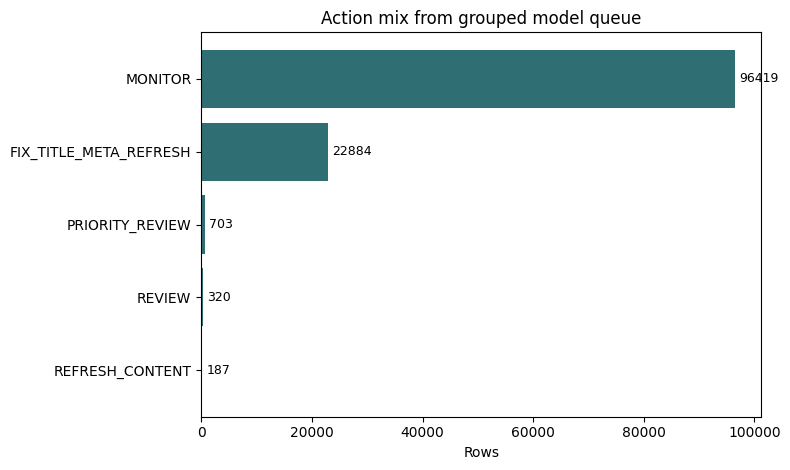

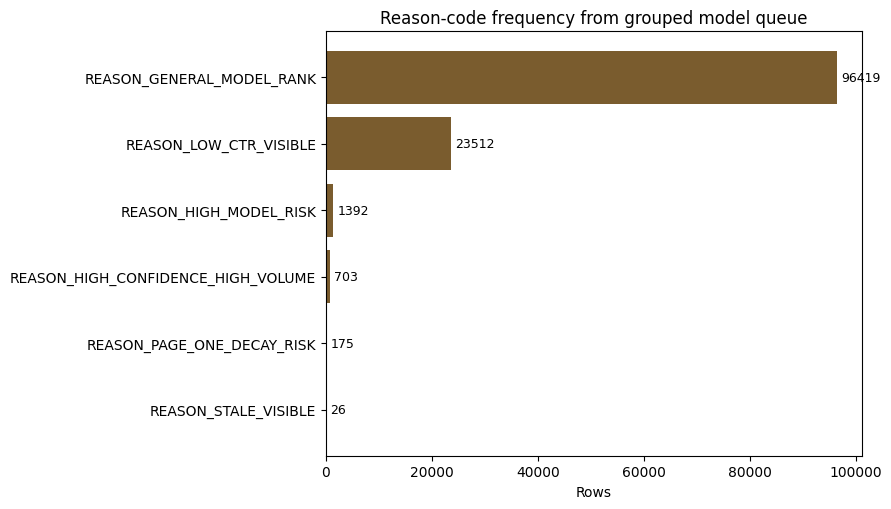

,artifact,path,rows
0,ranked_queue_csv,work/outputs/w07_grouped_action_queue.csv,120513
1,metrics_json,work/outputs/w07_action_playbook_metrics.json,1
2,action_mix_figure,work/figures/w07_action_mix.png,5
3,reason_code_figure,work/figures/w07_reason_code_frequency.png,6


{
  "rows_scored": 120513,
  "clients": 41,
  "base_declining_rate": 0.4329,
  "grouped_precision_at_10": 0.9,
  "grouped_precision_at_50": 0.52,
  "grouped_precision_at_500": 0.472,
  "top50_observed_right_picks": 26,
  "top500_observed_right_picks": 236,
  "review_minutes_per_page_assumption": 12,
  "top50_review_hours": 10.0,
  "top500_review_hours": 100.0,
  "top50_observed_right_picks_per_hour": 2.6,
  "top500_observed_right_picks_per_hour": 2.36,
  "archetype_counts": {
    "Lower-priority monitor": 96419,
    "Visible, underperforming CTR": 22884,
    "High-confidence decline risk, high volume": 703,
    "Model-risk review candidate": 320,
    "Stale but visible": 187
  },
  "action_counts": {
    "MONITOR": 96419,
    "FIX_TITLE_META_REFRESH": 22884,
    "PRIORITY_REVIEW": 703,
    "REVIEW": 320,
    "REFRESH_CONTENT": 187
  },
  "reason_code_counts": {
    "REASON_GENERAL_MODEL_RANK": 96419,
    "REASON_LOW_CTR_VISIBLE": 23512,
    "REASON_HIGH_MODEL_RISK": 1392,
    "REASON_H

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

queue_columns = [
    "rank",
    "content_id",
    "client_id",
    "grouped_probability",
    "reason_codes",
    "archetype",
    "action_label",
    "impressions_90d",
    "ctr",
    "avg_position",
    "visible_valid_position",
    "ctr_gap_score",
    "log_impressions_90d",
    "days_since_last_update",
    "freshness_score",
]
queue_path = OUTPUT_DIR / "w07_grouped_action_queue.csv"
metrics_path = OUTPUT_DIR / "w07_action_playbook_metrics.json"
action_figure_path = FIGURE_DIR / "w07_action_mix.png"
reason_figure_path = FIGURE_DIR / "w07_reason_code_frequency.png"

ranked_queue[queue_columns].to_csv(queue_path, index=False)

plt.style.use("default")
fig, ax = plt.subplots(figsize=(8, 4.8))
action_plot = action_counts.sort_values("rows", ascending=True)
ax.barh(action_plot["action_label"], action_plot["rows"], color="#2f6f73")
ax.set_title("Action mix from grouped model queue")
ax.set_xlabel("Rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(action_figure_path, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.2))
reason_plot = reason_counts.sort_values("rows", ascending=True)
ax.barh(reason_plot["reason_code"], reason_plot["rows"], color="#7a5c2e")
ax.set_title("Reason-code frequency from grouped model queue")
ax.set_xlabel("Rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(reason_figure_path, dpi=160)
plt.show()

metrics_payload = {
    "rows_scored": int(len(ranked_queue)),
    "clients": int(ranked_queue["client_id"].nunique()),
    "base_declining_rate": round(float(y.mean()), 4),
    "grouped_precision_at_10": round(float(precision_at_k_from_ranked(ranked_queue, 10)), 4),
    "grouped_precision_at_50": round(float(precision_at_k_from_ranked(ranked_queue, 50)), 4),
    "grouped_precision_at_500": round(float(precision_at_k_from_ranked(ranked_queue, 500)), 4),
    "top50_observed_right_picks": int(ranked_queue.head(50)["is_declining_label"].sum()),
    "top500_observed_right_picks": int(ranked_queue.head(500)["is_declining_label"].sum()),
    "review_minutes_per_page_assumption": REVIEW_MINUTES_PER_PAGE,
    "top50_review_hours": round(float(review_hours_top50), 2),
    "top500_review_hours": round(float(review_hours_top500), 2),
    "top50_observed_right_picks_per_hour": round(float((p50 * 50) / review_hours_top50), 4),
    "top500_observed_right_picks_per_hour": round(float((p500 * 500) / review_hours_top500), 4),
    "archetype_counts": {row["archetype"]: int(row["rows"]) for _, row in archetype_counts.iterrows()},
    "action_counts": {row["action_label"]: int(row["rows"]) for _, row in action_counts.iterrows()},
    "reason_code_counts": {row["reason_code"]: int(row["rows"]) for _, row in reason_counts.iterrows()},
    "ranking_source": "grouped_probability from GroupKFold(client_id) out-of-fold scoring",
    "queue_path": str(queue_path.relative_to(REPO_ROOT)),
    "figure_paths": [str(action_figure_path.relative_to(REPO_ROOT)), str(reason_figure_path.relative_to(REPO_ROOT))],
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2) + "\n")

export_receipt = pd.DataFrame(
    [
        {"artifact": "ranked_queue_csv", "path": str(queue_path.relative_to(REPO_ROOT)), "rows": len(ranked_queue)},
        {"artifact": "metrics_json", "path": str(metrics_path.relative_to(REPO_ROOT)), "rows": 1},
        {"artifact": "action_mix_figure", "path": str(action_figure_path.relative_to(REPO_ROOT)), "rows": len(action_counts)},
        {"artifact": "reason_code_figure", "path": str(reason_figure_path.relative_to(REPO_ROOT)), "rows": len(reason_counts)},
    ]
)
display(export_receipt)
print(json.dumps(metrics_payload, indent=2))

assert queue_path.exists() and queue_path.stat().st_size > 0
assert metrics_path.exists() and metrics_path.stat().st_size > 0
assert action_figure_path.exists() and action_figure_path.stat().st_size > 0
assert reason_figure_path.exists() and reason_figure_path.stat().st_size > 0

## Self-check

- [x] Every section filled: markdown thinking and code receipts are both present
- [x] Runs top to bottom with no errors
- [x] No client names, URLs, or private queries are printed
- [x] Claims use careful words: observed, measured, directional, and decision-support
- [x] Ranked queue CSV is written locally to `work/outputs/` and stays ignored by git
- [x] Figures are written to `work/figures/` for the paper
- [x] Metrics JSON is written to `work/outputs/` as a receipt
- [x] Committed to `work/notebooks/` after execution

## 6. Five-minute demo outline

**Question (~30s).** When FlyRank has limited reviewer time across many content queues, which pages should an editor inspect first?

**Method (~60s).** I compared two ranking approaches on the same decision: a seven-feature, depth-4 decision tree scored with `GroupKFold(client_id)` and a transparent baseline using CTR, visibility, volume, and freshness signals. March 2026 was the development month, and June 2026 was kept as the sealed check.

**Chart (~60s).** The figure below uses `work/figures/w07_action_mix.png`.

![Action mix for the ranked review queue](../figures/w07_action_mix.png)

It shows that the ranked output is mainly a reviewer-facing queue of monitor and visible underperforming-CTR cases, not a set of automatic edits.

**Honest result (~90s).** The result is mixed. In March, the model led at Precision@10, measuring 0.90 versus 0.80 for the baseline. In June, the model tied the baseline at Precision@10, with both measuring 1.00. At wider review depths, the transparent baseline led at Precision@50 and Precision@500 on both March and June. That suggests the small tree is useful for a narrow first look, while the rule remains the better default for larger batches.

**Recommendation (~60s).** Use the model for the first ~10 pages of a review batch, where a short prioritized list is useful. Use the transparent baseline for wider batches because it measured better at P@50 and P@500 on both splits and is easier to explain. In both cases, keep a human reviewer on every action: the queue supports judgment, but it does not publish, edit, de-index, or make client-facing decisions by itself.


## 7. Shareable cuts

**Social post draft.** I tested a content-review ranking problem as decision support, not automation: a seven-feature depth-4 decision tree against a transparent CTR, visibility, volume, and freshness baseline. The honest result was mixed. The model was stronger for the narrowest March review queue and tied at June P@10, while the transparent baseline led at wider P@50 and P@500 cutoffs on both splits. That is the useful lesson: careful applied ML is not just asking whether a model wins, but finding where it helps, where a simpler rule is better, and how to keep the result auditable for the humans using it.

**Employer-facing summary.** I built a public-safe content review ranking workflow that compares a simple decision tree with a transparent rule baseline for deciding which pages an editor should inspect first. The work uses FlyRank warehouse-scale data, moving from starter-scale analysis to 120,513 March page rows and a sealed 139,347-row June check. It showed a mixed result: the model was useful for the narrowest review queue, while the transparent baseline measured better for wider batches, so the recommendation keeps both methods human-reviewed and scoped to where each performed best.
